## Get the dataset

This classification algorithm will be trained and run on "gpiosenka/cards-image-datasetclassification" available to download directly at https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/data or by using the kaggle api through CLI with the commands in bash: 

 1. kaggle datasets download gpiosenka/cards-image-datasetclassification ; dataset will be downloaded as zip

 2. unzip "cards-image-datasetclassification.zip" -d "desired-folder/" ; unzip to desired dataset folder
 
 3. rm "cards-image-datasetclassification.zip" ; remove zip


In [1]:
# get libs

import torch 
import torch.nn as nn 
import torch.optim as optim # Optimizers
from torch.utils.data import Dataset, DataLoader # Data conversion to tensor format and batches
import torchvision
import torchvision.transforms as transforms # Rescaling img and convrtig to tensor
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import gc
import sys

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
PyTorch version 2.7.0+cu128
Torchvision version 0.22.0+cu128
Numpy version 2.1.3
Pandas version 2.2.3


In [2]:
# Check device availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## Prepare Datasets and DataLoader

In [3]:
#Define data collector
class CardCollector(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [4]:
data_train = "D:/#Git/neural-networks-playground/datadir/cards-image-dataset/train"
data_valid = "D:/#Git/neural-networks-playground/datadir/cards-image-dataset/valid"
data_test = "D:/#Git/neural-networks-playground/datadir/cards-image-dataset/test"

tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train = CardCollector(data_dir=data_train, transform=tf)
valid = CardCollector(data_dir=data_valid, transform=tf)
test  = CardCollector(data_dir=data_test , transform=tf)

train_loader = DataLoader(train, batch_size=32, shuffle= True)
valid_loader = DataLoader(valid, batch_size=32, shuffle=False)
test_loader  = DataLoader(test , batch_size=32, shuffle=False)

In [5]:
print("\t----- Before Dataloading -----")
print(len(train))

image, label = train[345]
print(label)
print(image.shape)

print("\t----- After Dataloading -----")
for image_loaded, label_loaded in train_loader:
    break

print(image_loaded.shape, label_loaded.shape)
print(label_loaded)

	----- Before Dataloading -----
7624
2
torch.Size([3, 128, 128])
	----- After Dataloading -----
torch.Size([32, 3, 128, 128]) torch.Size([32])
tensor([ 4,  4, 48,  4,  2, 47, 47, 29, 27, 46, 45, 44, 27,  2, 36, 29, 23, 48,
        13, 20,  2, 15, 22,  2, 19, 27, 42, 31, 51, 45, 51, 31])


In [6]:
class_labels = {v:k for k, v in ImageFolder(data_train).class_to_idx.items()}
print(class_labels)

{0: 'ace of clubs', 1: 'ace of diamonds', 2: 'ace of hearts', 3: 'ace of spades', 4: 'eight of clubs', 5: 'eight of diamonds', 6: 'eight of hearts', 7: 'eight of spades', 8: 'five of clubs', 9: 'five of diamonds', 10: 'five of hearts', 11: 'five of spades', 12: 'four of clubs', 13: 'four of diamonds', 14: 'four of hearts', 15: 'four of spades', 16: 'jack of clubs', 17: 'jack of diamonds', 18: 'jack of hearts', 19: 'jack of spades', 20: 'joker', 21: 'king of clubs', 22: 'king of diamonds', 23: 'king of hearts', 24: 'king of spades', 25: 'nine of clubs', 26: 'nine of diamonds', 27: 'nine of hearts', 28: 'nine of spades', 29: 'queen of clubs', 30: 'queen of diamonds', 31: 'queen of hearts', 32: 'queen of spades', 33: 'seven of clubs', 34: 'seven of diamonds', 35: 'seven of hearts', 36: 'seven of spades', 37: 'six of clubs', 38: 'six of diamonds', 39: 'six of hearts', 40: 'six of spades', 41: 'ten of clubs', 42: 'ten of diamonds', 43: 'ten of hearts', 44: 'ten of spades', 45: 'three of clu

## Build Classifier Model

In [ ]:
ch_size = 3 # number of initial channel, 3 for RGB 
out_size = 53 # number of classes to predict

class ConvNet(nn.Module):
    def __init__(self, n_classes = 53):
        super(ConvNet, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(ch_size, 32, (3,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, (3,3)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 32, (3,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
       
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, out_size)
            # nn.Softmax() -- No need for softmax as we will use CrossEntropyLoss which combines LogSoftmax and NNLoss
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        out = self.classifier(features)
        return out



In [10]:
# Print the model
model = ConvNet()
print(model)

ConvNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(

In [11]:
model.to(device)

ConvNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(

## Define training program

In [16]:
torch.cuda.empty_cache()
gc.collect()

3648

In [17]:
n_epochs = 15
train_losses, val_losses = [], []

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

model = ConvNet(n_classes=53)
model.to(device)

ConvNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(

In [18]:
for epoch in range(n_epochs):
    # Training phase
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc='Training loop'):
        # Send batches to device
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                   # Send backpropagation and compute gradients
        optimizer.step()                  #Update model parameters
        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc='Validation loop'):
            # Send batches to device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)

    val_loss = running_loss / len(valid_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{n_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")

    

Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/15 - Train loss: 3.9746537353659726, Validation loss: 3.973186994948477


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 14/15 - Train loss: 3.9752946045065976, Validation loss: 3.9730973153744102


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 15/15 - Train loss: 3.97367126193652, Validation loss: 3.9731762940028927


## Vizualise losses

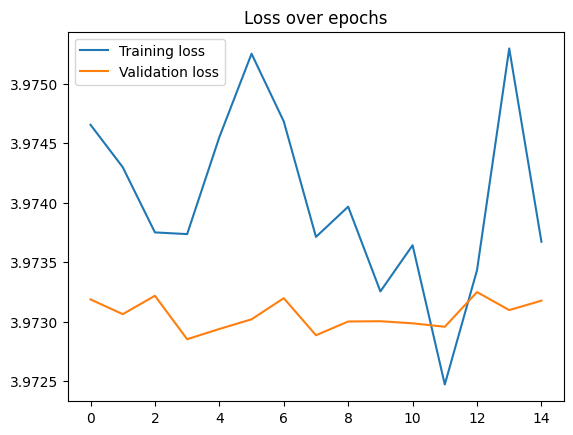

In [19]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()